# RQ2 / RQ3 / RQ4 — 30-Seed Robustness Evaluation

Re-runs the full compression pipeline 30 times with different model training seeds, mirroring the RQ1 SMOTE 30-seed evaluation. Produces mean ± std for every (Model, Dataset, Technique) combination.

## Design choices

- **Seeds 42..71** (matches the RQ1 SMOTE 30-seed protocol). Your canonical seed=42 run is the first seed in the loop.
- **Data split fixed**. The train/test split, RFE features, scalers, and IQR caps are loaded from `rq2_models/` (fit once on seed=42). This isolates *model variance* from *data-split variance*, matching the RQ1 SMOTE 30-seed approach (which produces the small stds in the RQ1 results table).
- **Per seed, retrain everything**. Each seed retrains all baselines (RF / MLP / XGB on static + dynamic), runs all compression (quantization, pruning, distillation), evaluates, and appends one row per (Model, Dataset, Technique) to the results.
- **Checkpointing**. Partial CSV saved every 5 seeds — if the run crashes you can resume by editing `START_SEED` below.
- **Runtime estimate**. ~12–18 min per seed → 6–9 hours for 30 seeds. Run overnight.

## What gets reported

For each (Model, Dataset, Technique), the aggregation cell at the end produces `Acc_mean ± Acc_std`, `F1_mean ± F1_std`, `Size_MB_mean`, `Latency_ms_mean`. Saved to `rq2_results_30seed.csv` (long format) and `rq2_summary_30seed.csv` (wide aggregated).

## 1. Setup — load fixed preprocessed data

In [7]:
# Configuration
BASE_SEED   = 42                    # First seed (matches RQ1 SMOTE 30-seed)
N_SEEDS     = 30                    # Total seeds → 42..71
START_OFFSET = 11                    # Resume offset; e.g. 5 to skip first 5 seeds
SEEDS       = [BASE_SEED + i for i in range(N_SEEDS)]
CHECKPOINT_EVERY = 5     # Save partial CSV every N seeds
INCLUDE_DISTILLATION = True   # Slow (~5 min/seed) — set False to skip

import os
import time
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import tensorflow_model_optimization as tfmot

import onnx
import onnxruntime as rt
from onnxruntime.quantization import quantize_dynamic, QuantType
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from onnxmltools.convert import convert_xgboost
from onnxmltools.convert.common.data_types import (
    FloatTensorType as OnnxFloatTensorType)
from onnx import helper

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# Working directory for per-seed temporary models
TMP_DIR = "rq2_30seed_tmp"
os.makedirs(TMP_DIR, exist_ok=True)

# ── Load fixed preprocessed arrays ────────────────────
X_train_s = np.load("rq2_models/X_train_s.npy")
X_test_s  = np.load("rq2_models/X_test_s.npy")
y_train_s = np.load("rq2_models/y_train_s.npy")
y_test_s  = np.load("rq2_models/y_test_s.npy")

X_train_d = np.load("rq2_models/X_train_d.npy")  # 56 features (post-RFE)
X_test_d  = np.load("rq2_models/X_test_d.npy")
y_train_d = np.load("rq2_models/y_train_d.npy")
y_test_d  = np.load("rq2_models/y_test_d.npy")

n_classes_d = len(np.unique(y_train_d))

print(f"Static  : train {X_train_s.shape} | test {X_test_s.shape}")
print(f"Dynamic : train {X_train_d.shape} | test {X_test_d.shape} ({n_classes_d} classes)")
print(f"\nSeeds  : {SEEDS[START_OFFSET]} .. {SEEDS[-1]}  ({N_SEEDS-START_OFFSET} runs)")
print(f"Distillation: {'enabled' if INCLUDE_DISTILLATION else 'disabled'}")

Static  : train (286244, 323) | test (71561, 323)
Dynamic : train (13455, 56) | test (3364, 56) (12 classes)

Seeds  : 53 .. 71  (19 runs)
Distillation: enabled


## 2. Helper functions

In [8]:
XGB_PARAMS = dict(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", n_jobs=-1)

def get_size_mb(fp):
    return os.path.getsize(fp) / (1024 * 1024)

def evaluate_sklearn(model, X_te, y_te, task):
    yp = model.predict(X_te)
    return {
        "accuracy": accuracy_score(y_te, yp),
        "f1"      : f1_score(y_te, yp,
                             average="binary" if task=="binary" else "weighted",
                             zero_division=0),
    }

def evaluate_keras(model, X_te, y_te, task):
    p = model.predict(X_te, verbose=0)
    yp = (p > 0.5).astype(int).flatten() if task=="binary" else np.argmax(p, axis=1)
    return {
        "accuracy": accuracy_score(y_te, yp),
        "f1"      : f1_score(y_te, yp,
                             average="binary" if task=="binary" else "weighted",
                             zero_division=0),
    }

def evaluate_tflite(interp, X_te, y_te, task):
    idx_in  = interp.get_input_details()[0]["index"]
    idx_out = interp.get_output_details()[0]["index"]
    preds = []
    for i in range(len(X_te)):
        interp.set_tensor(idx_in, X_te[i:i+1].astype(np.float32))
        interp.invoke()
        preds.append(interp.get_tensor(idx_out)[0])
    preds = np.array(preds)
    yp = (preds > 0.5).astype(int).flatten() if task=="binary" else np.argmax(preds, axis=1)
    return {
        "accuracy": accuracy_score(y_te, yp),
        "f1"      : f1_score(y_te, yp,
                             average="binary" if task=="binary" else "weighted",
                             zero_division=0),
    }

def evaluate_onnx(sess, X_te, y_te, task):
    inp = sess.get_inputs()[0].name
    out = sess.get_outputs()[0].name
    raw = sess.run([out], {inp: X_te.astype(np.float32)})[0]
    yp  = (raw > 0.5).astype(int).flatten() if task=="binary" else raw.flatten().astype(int)
    return {
        "accuracy": accuracy_score(y_te, yp),
        "f1"      : f1_score(y_te, yp,
                             average="binary" if task=="binary" else "weighted",
                             zero_division=0),
    }

def rf_to_onnx(model, n_features, fp, opset=17):
    init_type = [("float_input", FloatTensorType([None, n_features]))]
    onnx_model = convert_sklearn(
        model, initial_types=init_type,
        options={id(model): {"zipmap": False}}, target_opset=opset)
    del onnx_model.opset_import[:]
    onnx_model.opset_import.extend([
        helper.make_opsetid("", opset),
        helper.make_opsetid("ai.onnx.ml", 3)])
    with open(fp, "wb") as f:
        f.write(onnx_model.SerializeToString())

def xgb_to_onnx(model, n_features, fp, opset=15):
    init_type = [("float_input", OnnxFloatTensorType([None, n_features]))]
    onnx_model = convert_xgboost(model, initial_types=init_type)
    del onnx_model.opset_import[:]
    onnx_model.opset_import.extend([
        helper.make_opsetid("", opset),
        helper.make_opsetid("ai.onnx.ml", 3)])
    with open(fp, "wb") as f:
        f.write(onnx_model.SerializeToString())

print("✓ Helpers ready")

✓ Helpers ready


## 3. Per-seed pipeline functions

In [9]:
# ── Build Keras MLP teacher ───────────────────────────
def build_keras_mlp(input_dim, n_classes, task="binary"):
    inputs = keras.Input(shape=(input_dim,))
    x = keras.layers.Dense(256, activation="relu")(inputs)
    x = keras.layers.Dense(128, activation="relu")(x)
    if task == "binary":
        out, loss = keras.layers.Dense(1, activation="sigmoid")(x), "binary_crossentropy"
    else:
        out, loss = keras.layers.Dense(n_classes, activation="softmax")(x), "sparse_categorical_crossentropy"
    m = keras.Model(inputs, out)
    m.compile(optimizer="adam", loss=loss, metrics=["accuracy"])
    return m

# ── Build student MLP for distillation ────────────────
def build_student_mlp(input_dim, n_classes, task="binary"):
    inputs = keras.Input(shape=(input_dim,))
    x = keras.layers.Dense(128, activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.Dense(64, activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    if task == "binary":
        out = keras.layers.Dense(1, activation="sigmoid")(x)
    else:
        out = keras.layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inputs, out)

def distillation_loss(y_true, y_pred, teacher_pred,
                      task="binary", temperature=3.0, alpha=0.3):
    if task == "binary":
        y_pred       = tf.squeeze(y_pred, axis=-1)
        teacher_pred = tf.squeeze(tf.cast(teacher_pred, tf.float32), axis=-1)
        hard = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        soft = tf.keras.losses.binary_crossentropy(
            tf.sigmoid(teacher_pred / temperature),
            tf.sigmoid(y_pred       / temperature)) * (temperature ** 2)
    else:
        hard = tf.keras.losses.sparse_categorical_crossentropy(
            tf.cast(y_true, tf.int32), y_pred)
        teacher_soft = tf.nn.softmax(tf.cast(teacher_pred, tf.float32) / temperature)
        student_soft = tf.nn.softmax(y_pred / temperature)
        soft = tf.keras.losses.categorical_crossentropy(
            teacher_soft, student_soft) * (temperature ** 2)
    return (1 - alpha) * hard + alpha * soft

def train_student(teacher, X_tr, y_tr, task="binary",
                  epochs=50, temperature=3.0, alpha=0.3, patience=5):
    n_classes = len(np.unique(y_tr))
    student   = build_student_mlp(X_tr.shape[1], n_classes, task)
    opt       = keras.optimizers.Adam(learning_rate=0.001)
    best_val, best_w, no_improve = 0, None, 0

    val_size = int(0.15 * len(X_tr))
    X_val, y_val = X_tr[-val_size:], y_tr[-val_size:]
    X_tr2, y_tr2 = X_tr[:-val_size], y_tr[:-val_size]
    teacher_preds = teacher.predict(X_tr2, verbose=0)

    bs = 512
    nb = len(X_tr2) // bs
    for epoch in range(epochs):
        idx = np.random.permutation(len(X_tr2))
        Xs, ys, ts = X_tr2[idx], y_tr2[idx], teacher_preds[idx]
        for b in range(nb):
            s, e = b*bs, (b+1)*bs
            X_b = tf.cast(Xs[s:e], tf.float32)
            y_b = tf.cast(ys[s:e], tf.float32)
            t_b = ts[s:e]
            with tf.GradientTape() as tape:
                yp   = student(X_b, training=True)
                loss = tf.reduce_mean(distillation_loss(
                    y_b, yp, t_b, task, temperature, alpha))
            grads = tape.gradient(loss, student.trainable_variables)
            opt.apply_gradients(zip(grads, student.trainable_variables))
        vp = student.predict(X_val, verbose=0)
        val_acc = (accuracy_score(y_val, (vp > 0.5).astype(int).flatten())
                   if task == "binary"
                   else accuracy_score(y_val, np.argmax(vp, axis=1)))
        if val_acc > best_val:
            best_val, best_w, no_improve = val_acc, student.get_weights(), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    student.set_weights(best_w)
    return student

# ── Prune MLP ─────────────────────────────────────────
def prune_mlp(keras_model, X_tr, y_tr, sparsity, task="binary"):
    pruning_params = {
        "pruning_schedule": tfmot.sparsity.keras.ConstantSparsity(
            sparsity, begin_step=0, frequency=100)}
    pruned = tfmot.sparsity.keras.prune_low_magnitude(
        keras_model, **pruning_params)
    pruned.compile(
        optimizer="adam",
        loss="binary_crossentropy" if task=="binary"
             else "sparse_categorical_crossentropy",
        metrics=["accuracy"])
    pruned.fit(
        X_tr, y_tr, epochs=20, batch_size=512,
        validation_split=0.15,
        callbacks=[
            tfmot.sparsity.keras.UpdatePruningStep(),
            keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
        verbose=0)
    return tfmot.sparsity.keras.strip_pruning(pruned)

# ── TFLite quantization ───────────────────────────────
def quantize_tflite(keras_model, X_sample, fp):
    def rep_dataset():
        for i in range(min(200, len(X_sample))):
            yield [X_sample[i:i+1].astype(np.float32)]
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = rep_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.float32
    converter.inference_output_type = tf.float32
    with open(fp, "wb") as f:
        f.write(converter.convert())

print("✓ Pipeline functions ready")

✓ Pipeline functions ready


## 4. The seed loop

In [10]:
def run_one_seed(seed):
    """Run the full compression pipeline once with the given seed.
    Returns a list of result dicts (one per Model × Dataset × Technique)."""
    rows = []
    np.random.seed(seed); tf.random.set_seed(seed)

    def add(model, dataset, technique, acc, f1, size_mb, baseline_acc=None):
        drop = (acc - baseline_acc) if baseline_acc is not None else 0.0
        rows.append({
            "Seed"      : seed,
            "Model"     : model,
            "Dataset"   : dataset,
            "Technique" : technique,
            "Accuracy"  : round(acc, 4),
            "F1"        : round(f1, 4),
            "Acc_Drop"  : round(drop, 4),
            "Size_MB"   : round(size_mb, 4),
        })

    # ──────────────────────────────────────────────────────────
    # 1. RANDOM FOREST
    # ──────────────────────────────────────────────────────────
    rf_static = RandomForestClassifier(
        n_estimators=200, max_depth=None, class_weight="balanced",
        n_jobs=-1, random_state=seed)
    rf_static.fit(X_train_s, y_train_s)
    fp = f"{TMP_DIR}/rf_static_baseline_{seed}.onnx"
    rf_to_onnx(rf_static, X_train_s.shape[1], fp)
    res = evaluate_sklearn(rf_static, X_test_s, y_test_s, "binary")
    base_rf_s = res["accuracy"]
    add("RF", "Static", "Baseline", res["accuracy"], res["f1"], get_size_mb(fp))

    rf_dynamic = RandomForestClassifier(
        n_estimators=200, max_depth=20, class_weight="balanced",
        n_jobs=-1, random_state=seed)
    rf_dynamic.fit(X_train_d, y_train_d)
    fp = f"{TMP_DIR}/rf_dynamic_baseline_{seed}.onnx"
    rf_to_onnx(rf_dynamic, X_train_d.shape[1], fp)
    res = evaluate_sklearn(rf_dynamic, X_test_d, y_test_d, "multiclass")
    base_rf_d = res["accuracy"]
    add("RF", "Dynamic", "Baseline", res["accuracy"], res["f1"], get_size_mb(fp))

    # RF pruning (reduce n_estimators)
    for n_trees, pct in [(100, 50), (50, 75), (25, 87)]:
        # Static
        rf_p = RandomForestClassifier(
            n_estimators=n_trees, max_depth=None, class_weight="balanced",
            n_jobs=-1, random_state=seed)
        rf_p.fit(X_train_s, y_train_s)
        fp = f"{TMP_DIR}/rf_static_pruned_{n_trees}_{seed}.onnx"
        rf_to_onnx(rf_p, X_train_s.shape[1], fp)
        res = evaluate_sklearn(rf_p, X_test_s, y_test_s, "binary")
        add("RF", "Static", f"Pruning {pct}% ({n_trees} trees)",
            res["accuracy"], res["f1"], get_size_mb(fp), base_rf_s)
        # Dynamic
        rf_p = RandomForestClassifier(
            n_estimators=n_trees, max_depth=20, class_weight="balanced",
            n_jobs=-1, random_state=seed)
        rf_p.fit(X_train_d, y_train_d)
        fp = f"{TMP_DIR}/rf_dynamic_pruned_{n_trees}_{seed}.onnx"
        rf_to_onnx(rf_p, X_train_d.shape[1], fp)
        res = evaluate_sklearn(rf_p, X_test_d, y_test_d, "multiclass")
        add("RF", "Dynamic", f"Pruning {pct}% ({n_trees} trees)",
            res["accuracy"], res["f1"], get_size_mb(fp), base_rf_d)

    # RF quantization (apply to baselines)
    for dataset, X_te, y_te, base, task in [
        ("Static",  X_test_s, y_test_s, base_rf_s, "binary"),
        ("Dynamic", X_test_d, y_test_d, base_rf_d, "multiclass"),
    ]:
        in_fp  = f"{TMP_DIR}/rf_{dataset.lower()}_baseline_{seed}.onnx"
        out_fp = f"{TMP_DIR}/rf_{dataset.lower()}_quant_{seed}.onnx"
        quantize_dynamic(in_fp, out_fp, weight_type=QuantType.QUInt8)
        sess = rt.InferenceSession(out_fp)
        res  = evaluate_onnx(sess, X_te, y_te, task)
        add("RF", dataset, "Quantization INT8",
            res["accuracy"], res["f1"], get_size_mb(out_fp), base)

    # ──────────────────────────────────────────────────────────
    # 2. MLP
    # ──────────────────────────────────────────────────────────
    keras.utils.set_random_seed(seed)
    mlp_s = build_keras_mlp(X_train_s.shape[1], 2, task="binary")
    mlp_s.fit(X_train_s, y_train_s, epochs=50, batch_size=512,
              validation_split=0.15,
              callbacks=[keras.callbacks.EarlyStopping(
                  patience=5, restore_best_weights=True)],
              verbose=0)
    fp_s = f"{TMP_DIR}/mlp_static_baseline_{seed}.keras"
    mlp_s.save(fp_s)
    res = evaluate_keras(mlp_s, X_test_s, y_test_s, "binary")
    base_mlp_s = res["accuracy"]
    add("MLP", "Static", "Baseline", res["accuracy"], res["f1"], get_size_mb(fp_s))

    keras.utils.set_random_seed(seed)
    mlp_d = build_keras_mlp(X_train_d.shape[1], n_classes_d, task="multiclass")
    mlp_d.fit(X_train_d, y_train_d, epochs=50, batch_size=256,
              validation_split=0.15,
              callbacks=[keras.callbacks.EarlyStopping(
                  patience=5, restore_best_weights=True)],
              verbose=0)
    fp_d = f"{TMP_DIR}/mlp_dynamic_baseline_{seed}.keras"
    mlp_d.save(fp_d)
    res = evaluate_keras(mlp_d, X_test_d, y_test_d, "multiclass")
    base_mlp_d = res["accuracy"]
    add("MLP", "Dynamic", "Baseline", res["accuracy"], res["f1"], get_size_mb(fp_d))

    # MLP quantization
    for dataset, model, X_tr, X_te, y_te, base, task in [
        ("Static",  mlp_s, X_train_s, X_test_s, y_test_s, base_mlp_s, "binary"),
        ("Dynamic", mlp_d, X_train_d, X_test_d, y_test_d, base_mlp_d, "multiclass"),
    ]:
        fp_q = f"{TMP_DIR}/mlp_{dataset.lower()}_quant_{seed}.tflite"
        quantize_tflite(model, X_tr, fp_q)
        interp = tf.lite.Interpreter(model_path=fp_q)
        interp.allocate_tensors()
        res = evaluate_tflite(interp, X_te, y_te, task)
        add("MLP", dataset, "Quantization INT8",
            res["accuracy"], res["f1"], get_size_mb(fp_q), base)

    # MLP pruning
    for sp in [0.25, 0.50, 0.75]:
        # Static
        keras.utils.set_random_seed(seed)
        m = prune_mlp(
            keras.models.load_model(fp_s),
            X_train_s, y_train_s, sp, "binary")
        fp = f"{TMP_DIR}/mlp_static_pruned_{int(sp*100)}_{seed}.keras"
        m.save(fp)
        res = evaluate_keras(m, X_test_s, y_test_s, "binary")
        add("MLP", "Static", f"Pruning {int(sp*100)}%",
            res["accuracy"], res["f1"], get_size_mb(fp), base_mlp_s)
        # Dynamic
        keras.utils.set_random_seed(seed)
        m = prune_mlp(
            keras.models.load_model(fp_d),
            X_train_d, y_train_d, sp, "multiclass")
        fp = f"{TMP_DIR}/mlp_dynamic_pruned_{int(sp*100)}_{seed}.keras"
        m.save(fp)
        res = evaluate_keras(m, X_test_d, y_test_d, "multiclass")
        add("MLP", "Dynamic", f"Pruning {int(sp*100)}%",
            res["accuracy"], res["f1"], get_size_mb(fp), base_mlp_d)

    # MLP distillation (slow — gated by flag)
    if INCLUDE_DISTILLATION:
        keras.utils.set_random_seed(seed)
        student_s = train_student(
            mlp_s, X_train_s, y_train_s, task="binary",
            epochs=100, temperature=5.0, alpha=0.5, patience=10)
        fp = f"{TMP_DIR}/mlp_static_student_{seed}.keras"
        student_s.save(fp)
        res = evaluate_keras(student_s, X_test_s, y_test_s, "binary")
        add("MLP", "Static", "Distillation (128→64)",
            res["accuracy"], res["f1"], get_size_mb(fp), base_mlp_s)

        keras.utils.set_random_seed(seed)
        student_d = train_student(
            mlp_d, X_train_d, y_train_d, task="multiclass",
            epochs=150, temperature=7.0, alpha=0.6, patience=15)
        fp = f"{TMP_DIR}/mlp_dynamic_student_{seed}.keras"
        student_d.save(fp)
        res = evaluate_keras(student_d, X_test_d, y_test_d, "multiclass")
        add("MLP", "Dynamic", "Distillation (128→64)",
            res["accuracy"], res["f1"], get_size_mb(fp), base_mlp_d)

    # ──────────────────────────────────────────────────────────
    # 3. XGBOOST
    # ──────────────────────────────────────────────────────────
    xgb_s = XGBClassifier(**XGB_PARAMS, random_state=seed)
    xgb_s.fit(X_train_s, y_train_s)
    fp = f"{TMP_DIR}/xgb_static_baseline_{seed}.onnx"
    xgb_to_onnx(xgb_s, X_train_s.shape[1], fp)
    res = evaluate_sklearn(xgb_s, X_test_s, y_test_s, "binary")
    base_xgb_s = res["accuracy"]
    add("XGB", "Static", "Baseline", res["accuracy"], res["f1"], get_size_mb(fp))

    xgb_d = XGBClassifier(**XGB_PARAMS, random_state=seed)
    xgb_d.fit(X_train_d, y_train_d)
    fp = f"{TMP_DIR}/xgb_dynamic_baseline_{seed}.onnx"
    xgb_to_onnx(xgb_d, X_train_d.shape[1], fp)
    res = evaluate_sklearn(xgb_d, X_test_d, y_test_d, "multiclass")
    base_xgb_d = res["accuracy"]
    add("XGB", "Dynamic", "Baseline", res["accuracy"], res["f1"], get_size_mb(fp))

    # XGB pruning (reduce n_estimators)
    for n_rounds, pct in [(100, 67), (50, 83), (25, 92)]:
        xgb_p = XGBClassifier(
            **{**XGB_PARAMS, "n_estimators": n_rounds}, random_state=seed)
        xgb_p.fit(X_train_s, y_train_s)
        fp = f"{TMP_DIR}/xgb_static_pruned_{n_rounds}_{seed}.onnx"
        xgb_to_onnx(xgb_p, X_train_s.shape[1], fp)
        res = evaluate_sklearn(xgb_p, X_test_s, y_test_s, "binary")
        add("XGB", "Static", f"Pruning {pct}% ({n_rounds} rounds)",
            res["accuracy"], res["f1"], get_size_mb(fp), base_xgb_s)

        xgb_p = XGBClassifier(
            **{**XGB_PARAMS, "n_estimators": n_rounds}, random_state=seed)
        xgb_p.fit(X_train_d, y_train_d)
        fp = f"{TMP_DIR}/xgb_dynamic_pruned_{n_rounds}_{seed}.onnx"
        xgb_to_onnx(xgb_p, X_train_d.shape[1], fp)
        res = evaluate_sklearn(xgb_p, X_test_d, y_test_d, "multiclass")
        add("XGB", "Dynamic", f"Pruning {pct}% ({n_rounds} rounds)",
            res["accuracy"], res["f1"], get_size_mb(fp), base_xgb_d)

    # XGB quantization
    for dataset, X_te, y_te, base, task in [
        ("Static",  X_test_s, y_test_s, base_xgb_s, "binary"),
        ("Dynamic", X_test_d, y_test_d, base_xgb_d, "multiclass"),
    ]:
        in_fp  = f"{TMP_DIR}/xgb_{dataset.lower()}_baseline_{seed}.onnx"
        out_fp = f"{TMP_DIR}/xgb_{dataset.lower()}_quant_{seed}.onnx"
        quantize_dynamic(in_fp, out_fp, weight_type=QuantType.QUInt8)
        sess = rt.InferenceSession(out_fp)
        res  = evaluate_onnx(sess, X_te, y_te, task)
        add("XGB", dataset, "Quantization INT8",
            res["accuracy"], res["f1"], get_size_mb(out_fp), base)

    return rows

print("✓ Per-seed pipeline ready")

✓ Per-seed pipeline ready


## 5. Run the loop

In [11]:
print("="*60)
print(f"  RUNNING {N_SEEDS - START_OFFSET} SEEDS  "
      f"({SEEDS[START_OFFSET]} .. {SEEDS[-1]})")
print("="*60)

# Resume support
all_rows = []
ckpt_path = "rq2_results_30seed_partial.csv"
if START_OFFSET > 0 and os.path.exists(ckpt_path):
    print(f"\nResuming from {ckpt_path}")
    completed_seeds = set(SEEDS[:START_OFFSET])
    all_rows = pd.read_csv(ckpt_path).to_dict("records")
    all_rows = [r for r in all_rows if r["Seed"] in completed_seeds]
    print(f"  Loaded {len(all_rows)} rows from previous seeds")

t_start = time.perf_counter()
for i, seed in enumerate(SEEDS[START_OFFSET:], start=START_OFFSET):
    print(f"\n── Seed {seed}  ({i+1}/{N_SEEDS}) ──")
    t0 = time.perf_counter()
    try:
        rows = run_one_seed(seed)
        all_rows.extend(rows)
        elapsed = time.perf_counter() - t0
        total   = time.perf_counter() - t_start
        done    = i - START_OFFSET + 1
        eta     = total / done * (N_SEEDS - i - 1)
        print(f"  ✓ {len(rows)} results  |  {elapsed:.0f}s this seed  "
              f"|  ETA {eta/60:.0f} min remaining")

        if (i + 1) % CHECKPOINT_EVERY == 0:
            pd.DataFrame(all_rows).to_csv(ckpt_path, index=False)
            print(f"  ✓ Checkpoint saved ({len(all_rows)} rows)")

    except Exception as exc:
        print(f"  ✗ Seed {seed} failed: {exc}")
        pd.DataFrame(all_rows).to_csv(ckpt_path, index=False)
        raise
# Final save
df = pd.DataFrame(all_rows)
df.to_csv("rq2_results_30seed.csv", index=False)
print(f"\n{'='*60}")
print(f"  ✓ Complete. Total time: {(time.perf_counter()-t_start)/60:.1f} min")
print(f"  ✓ Saved rq2_results_30seed.csv ({len(df)} rows)")
print(f"{'='*60}")

  RUNNING 19 SEEDS  (53 .. 71)

Resuming from rq2_results_30seed_partial.csv
  Loaded 352 rows from previous seeds

── Seed 53  (12/30) ──


INFO:tensorflow:Assets written to: C:\Users\JESSEV~1\AppData\Local\Temp\tmpnj17qls8\assets


INFO:tensorflow:Assets written to: C:\Users\JESSEV~1\AppData\Local\Temp\tmpnj17qls8\assets


INFO:tensorflow:Assets written to: C:\Users\JESSEV~1\AppData\Local\Temp\tmpindfdgo5\assets


INFO:tensorflow:Assets written to: C:\Users\JESSEV~1\AppData\Local\Temp\tmpindfdgo5\assets


...

INFO:tensorflow:Assets written to: C:\Users\JESSEV~1\AppData\Local\Temp\tmpvr08_3e3\assets


INFO:tensorflow:Assets written to: C:\Users\JESSEV~1\AppData\Local\Temp\tmpvr08_3e3\assets


INFO:tensorflow:Assets written to: C:\Users\JESSEV~1\AppData\Local\Temp\tmp707e_87g\assets


INFO:tensorflow:Assets written to: C:\Users\JESSEV~1\AppData\Local\Temp\tmp707e_87g\assets


  ✓ 32 results  |  13261s this seed  |  ETA 0 min remaining
  ✓ Checkpoint saved (960 rows)

  ✓ Complete. Total time: 2849.6 min
  ✓ Saved rq2_results_30seed.csv (960 rows)


In [12]:
df = pd.read_csv("rq2_results_30seed_partial.csv")
print(df["Seed"].nunique())
print(sorted(df["Seed"].unique()))

30
[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]


## 6. Aggregate — mean ± std

In [13]:
df = pd.read_csv("rq2_results_30seed.csv")
print(f"Loaded {len(df)} rows from {df['Seed'].nunique()} seeds")

# Mean ± std per (Model, Dataset, Technique)
agg = df.groupby(["Model", "Dataset", "Technique"]).agg(
    Acc_mean   = ("Accuracy",  "mean"),
    Acc_std    = ("Accuracy",  "std"),
    F1_mean    = ("F1",        "mean"),
    F1_std     = ("F1",        "std"),
    Drop_mean  = ("Acc_Drop",  "mean"),
    Drop_std   = ("Acc_Drop",  "std"),
    Size_mean  = ("Size_MB",   "mean"),
    Size_std   = ("Size_MB",   "std"),
    N_seeds    = ("Seed",      "nunique"),
).round(4).reset_index()

# Pretty formatted columns
agg["Acc_str"]  = agg.apply(
    lambda r: f"{r['Acc_mean']:.4f} ± {r['Acc_std']:.4f}", axis=1)
agg["F1_str"]   = agg.apply(
    lambda r: f"{r['F1_mean']:.4f} ± {r['F1_std']:.4f}", axis=1)
agg["Size_str"] = agg.apply(
    lambda r: f"{r['Size_mean']:.3f} ± {r['Size_std']:.3f}", axis=1)

agg.to_csv("rq2_summary_30seed.csv", index=False)

# Display compact version
display_cols = ["Model", "Dataset", "Technique", "Acc_str", "F1_str",
                "Size_str", "Drop_mean", "N_seeds"]
display(agg[display_cols].rename(columns={
    "Acc_str": "Accuracy", "F1_str": "F1", "Size_str": "Size_MB",
    "Drop_mean": "Avg Drop"}))

print(f"\n✓ Saved rq2_summary_30seed.csv ({len(agg)} (Model, Dataset, Technique) groups)")

Loaded 960 rows from 30 seeds


,Model,Dataset,Technique,Accuracy,F1,Size_MB,Avg Drop,N_seeds
0,MLP,Dynamic,Baseline,0.8096 ± 0.0051,0.8066 ± 0.0056,0.586 ± 0.000,0.0000,30
1,MLP,Dynamic,Distillation (128→64),0.8138 ± 0.0047,0.8103 ± 0.0054,0.079 ± 0.000,0.0042,30
2,MLP,Dynamic,Pruning 25%,0.8126 ± 0.0040,0.8098 ± 0.0043,0.201 ± 0.000,0.0030,30
3,MLP,Dynamic,Pruning 50%,0.8126 ± 0.0050,0.8096 ± 0.0055,0.201 ± 0.000,0.0030,30
4,MLP,Dynamic,Pruning 75%,0.8122 ± 0.0050,0.8091 ± 0.0056,0.201 ± 0.000,0.0025,30
5,MLP,Dynamic,Quantization INT8,0.8093 ± 0.0047,0.8062 ± 0.0053,0.051 ± 0.000,-0.0003,30
6,MLP,Static,Baseline,0.9716 ± 0.0006,0.9739 ± 0.0005,1.352 ± 0.000,0.0000,30
7,MLP,Static,Distillation (128→64),0.9741 ± 0.0005,0.9761 ± 0.0005,0.206 ± 0.000,0.0025,30
8,MLP,Static,Pruning 25%,0.9722 ± 0.0006,0.9745 ± 0.0005,0.456 ± 0.000,0.0006,30
9,MLP,Static,Pruning 50%,0.9722 ± 0.0005,0.9745 ± 0.0004,0.456 ± 0.000,0.0006,30



✓ Saved rq2_summary_30seed.csv (32 (Model, Dataset, Technique) groups)


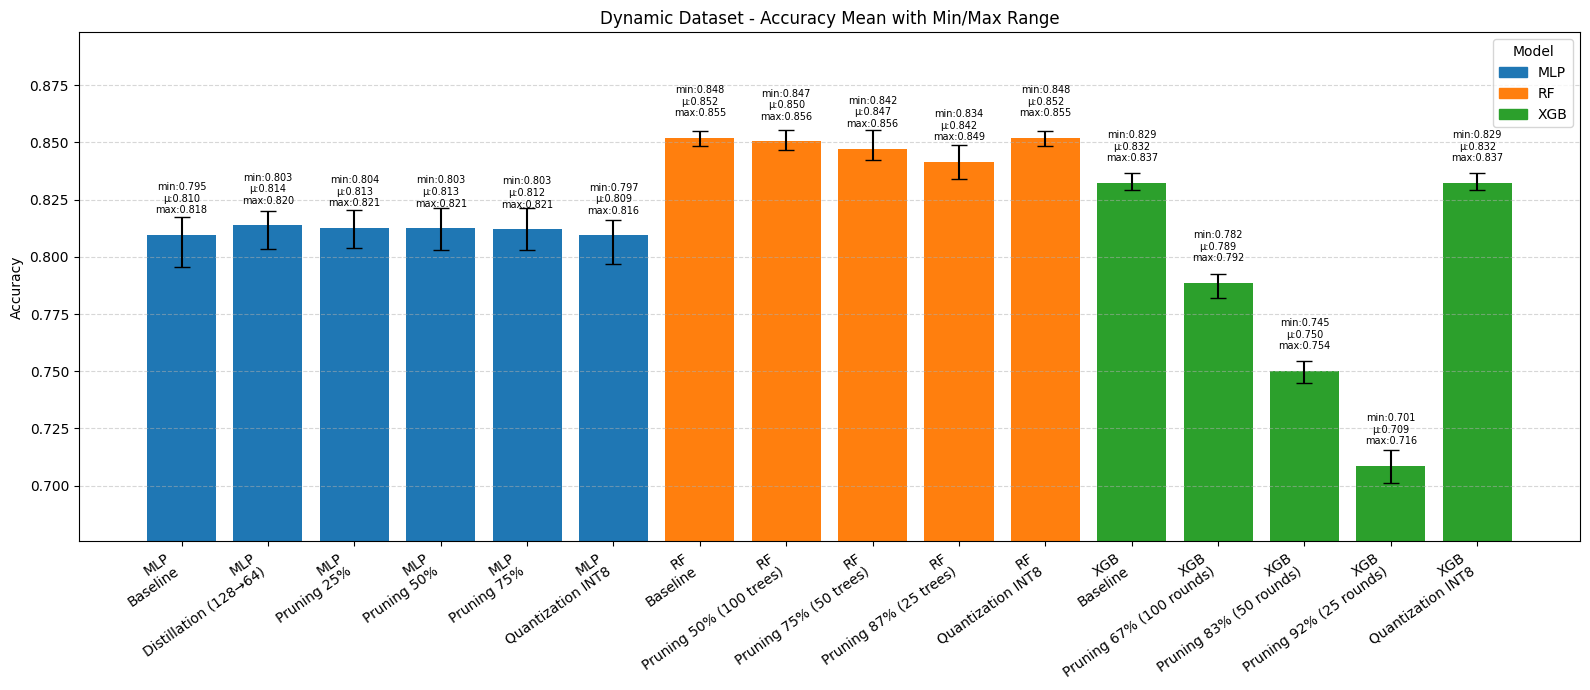

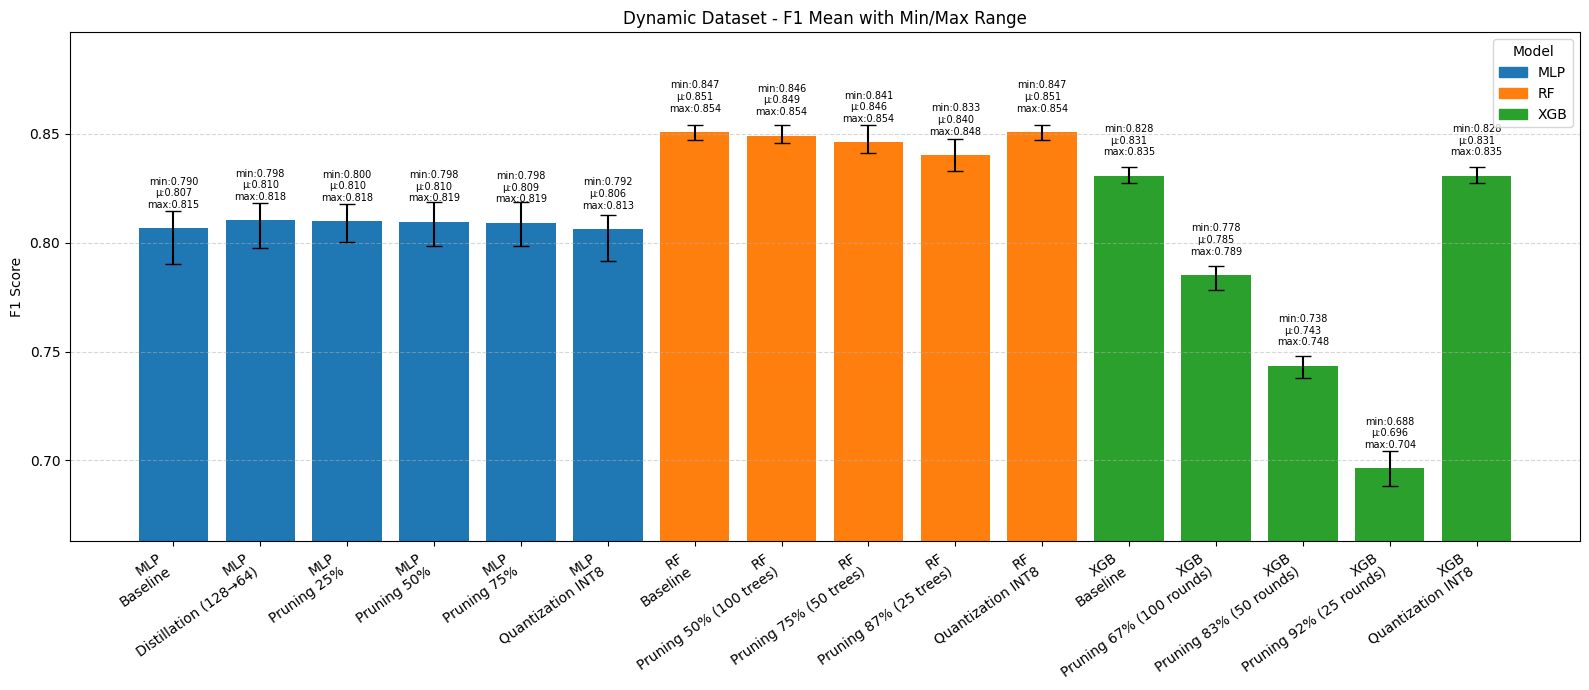

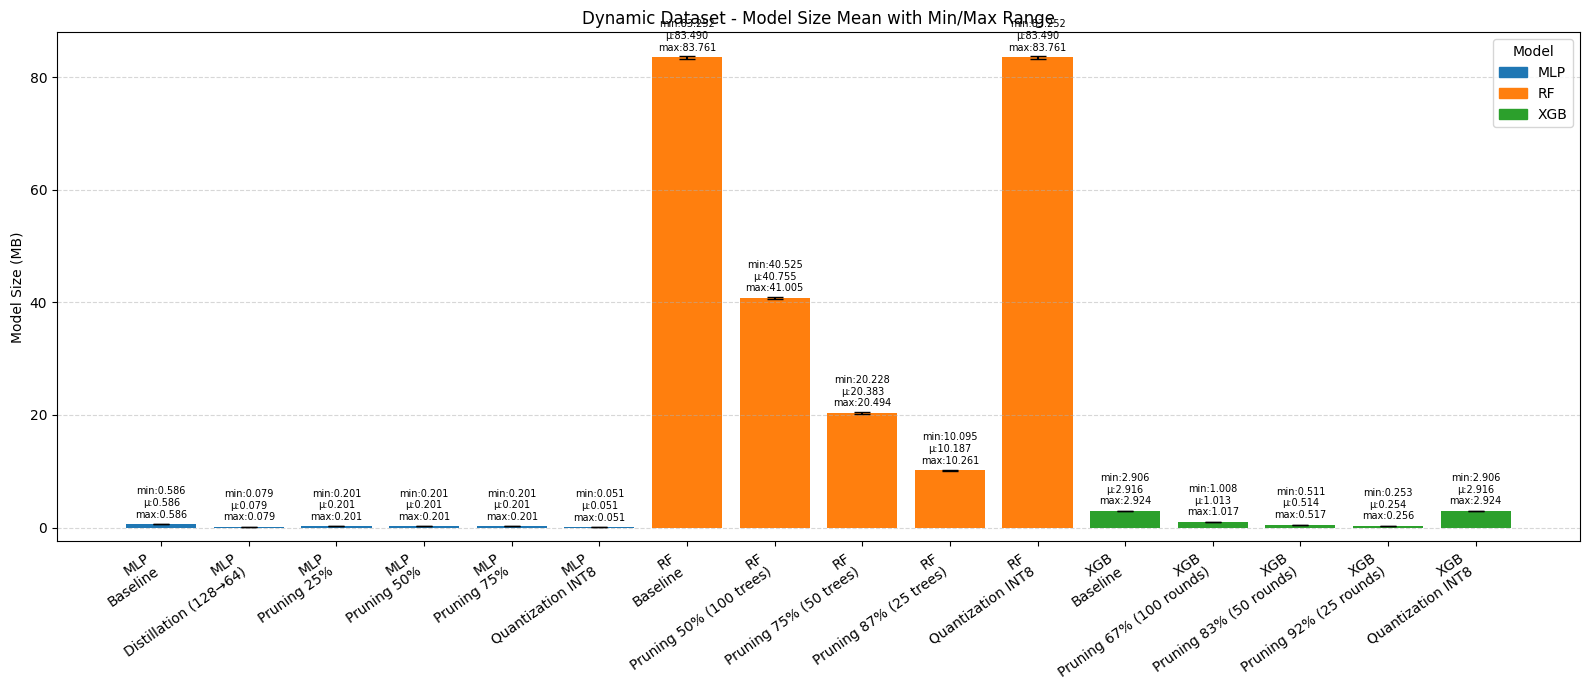

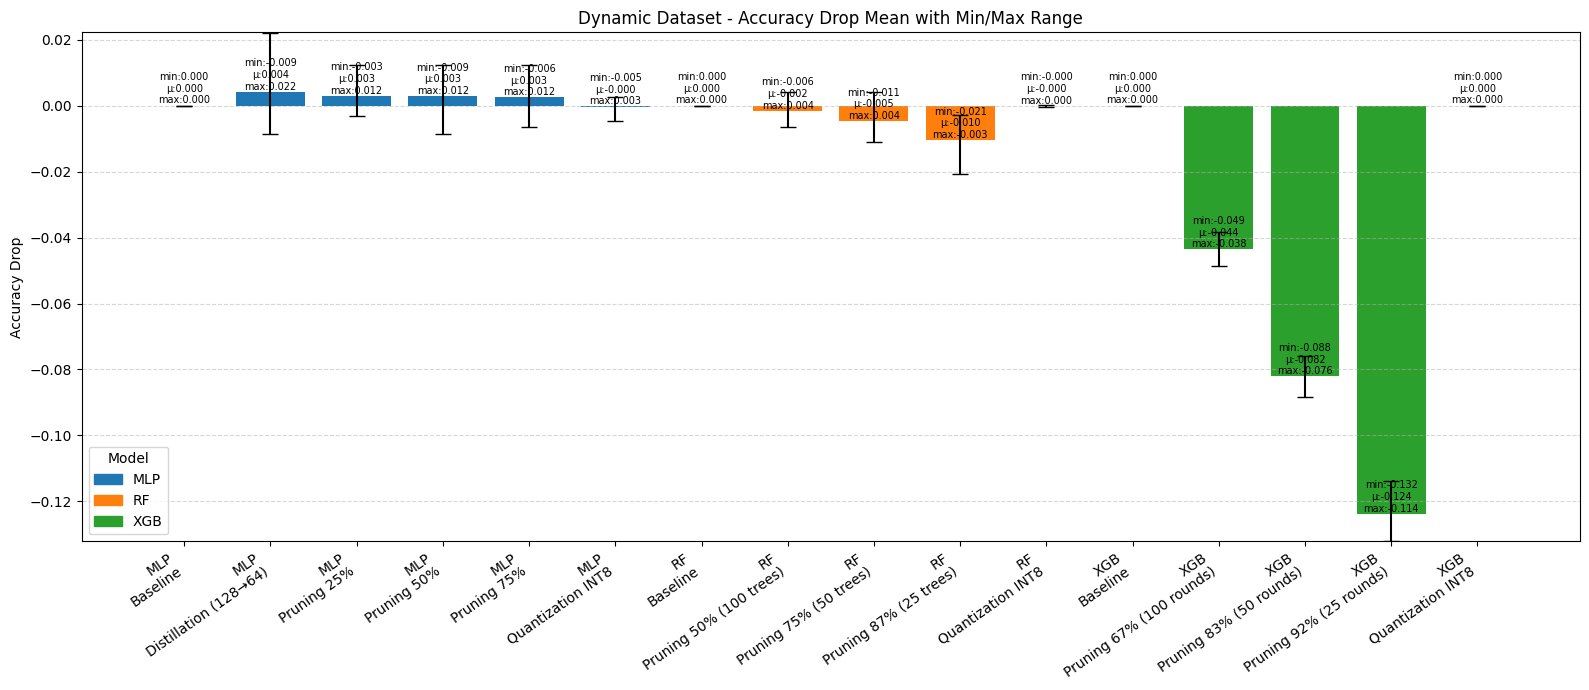

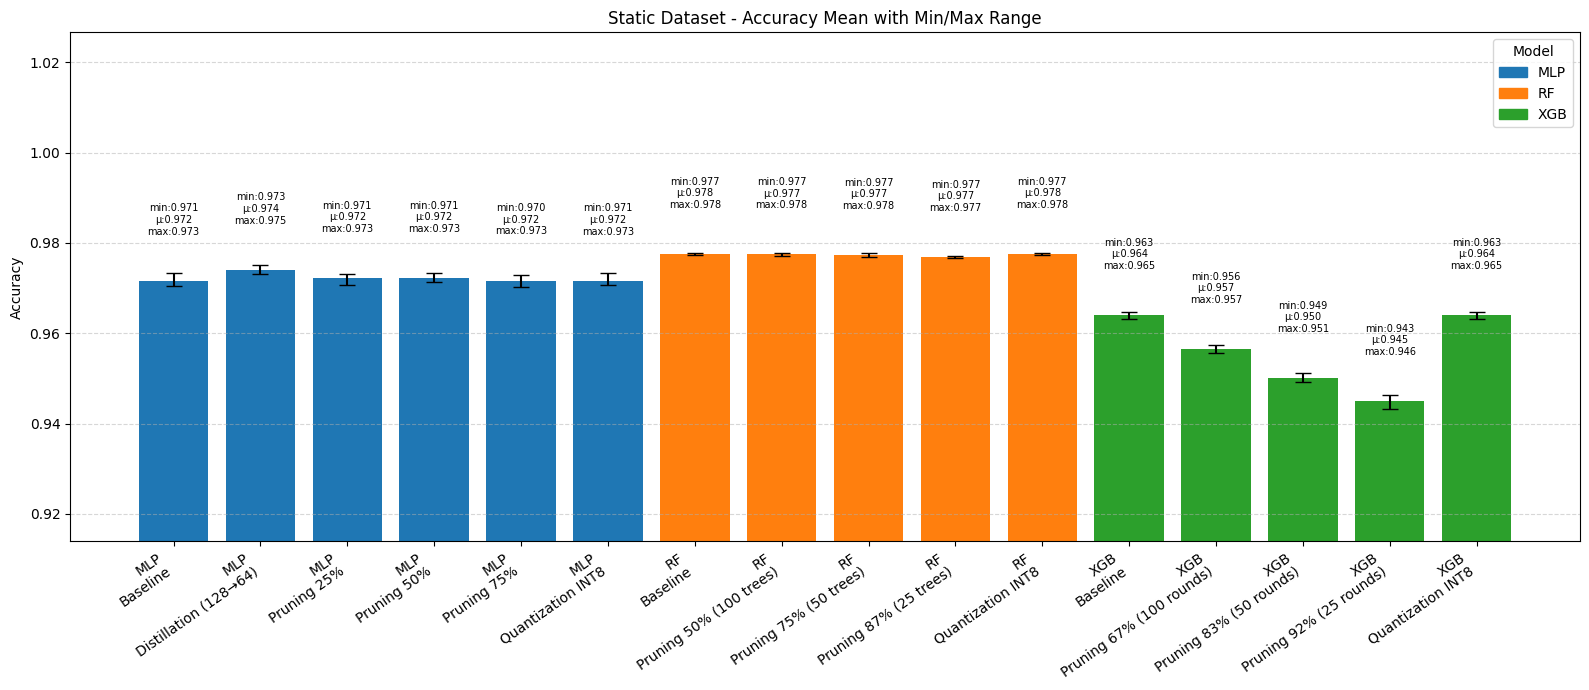

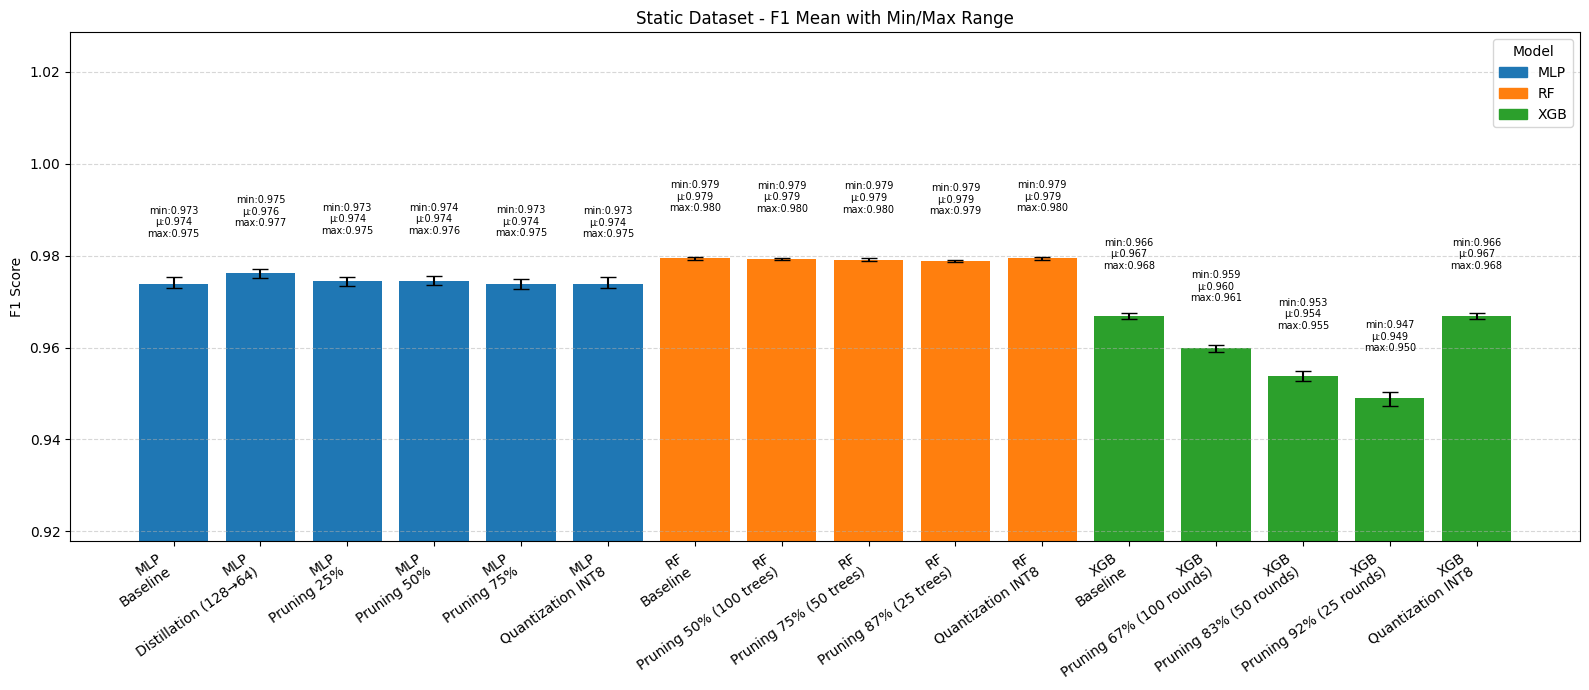

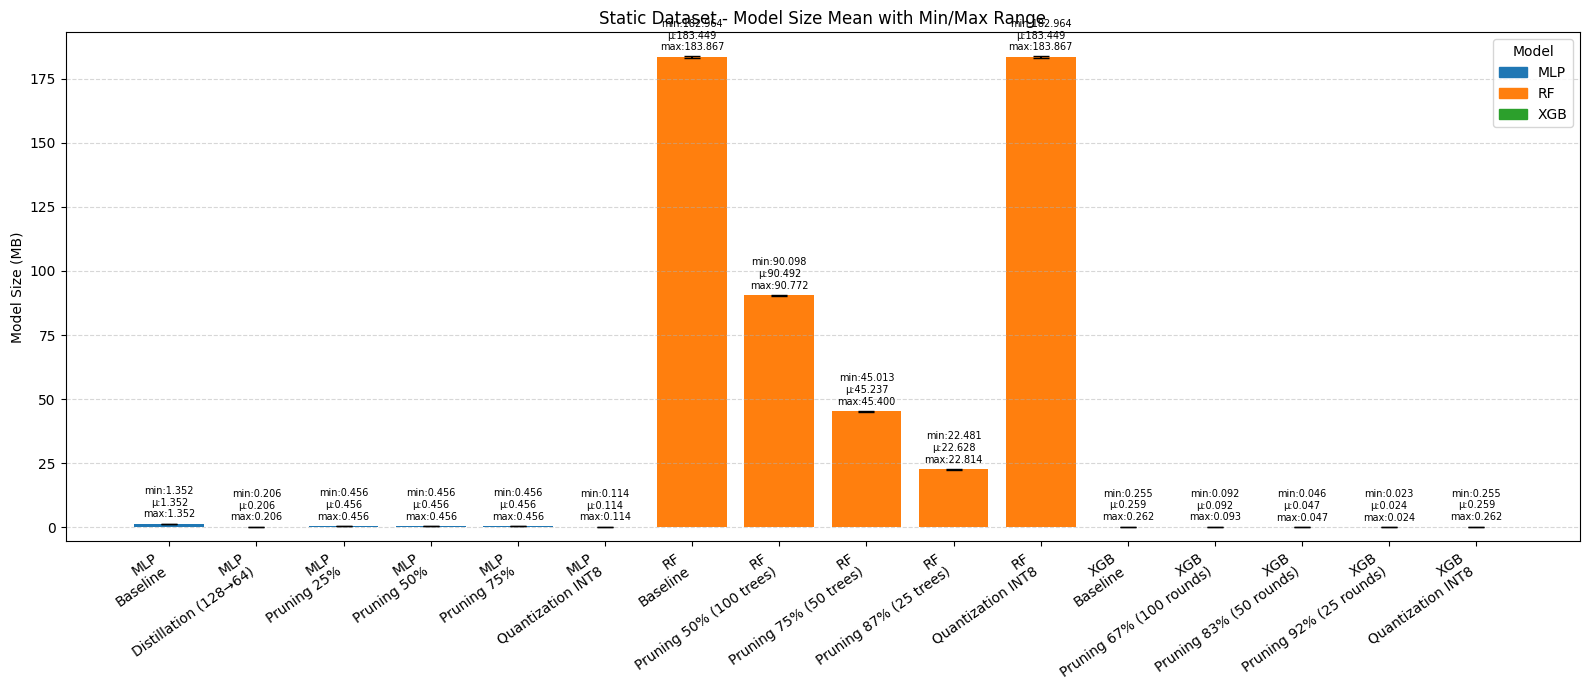

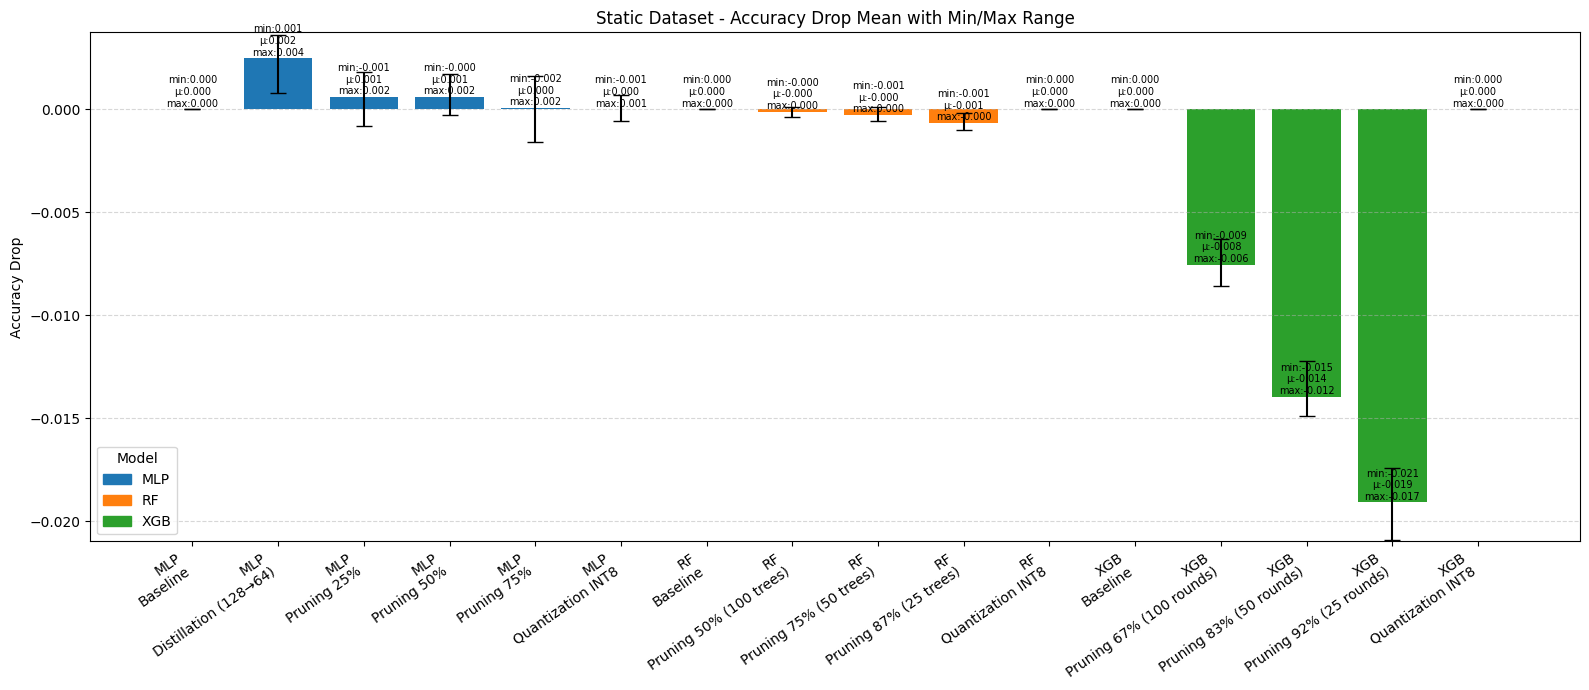

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("rq2_results_30seed.csv")

# -----------------------------
# Aggregate statistics
# -----------------------------
agg = df.groupby(["Model", "Dataset", "Technique"]).agg(

    # Accuracy
    Acc_mean=("Accuracy", "mean"),
    Acc_min=("Accuracy", "min"),
    Acc_max=("Accuracy", "max"),

    # F1
    F1_mean=("F1", "mean"),
    F1_min=("F1", "min"),
    F1_max=("F1", "max"),

    # Size
    Size_mean=("Size_MB", "mean"),
    Size_min=("Size_MB", "min"),
    Size_max=("Size_MB", "max"),

    # Accuracy Drop
    Drop_mean=("Acc_Drop", "mean"),
    Drop_min=("Acc_Drop", "min"),
    Drop_max=("Acc_Drop", "max"),

).reset_index()

# -----------------------------
# Colors by model
# -----------------------------
model_colors = {
    "MLP": "tab:blue",
    "RF": "tab:orange",
    "XGB": "tab:green"
}

# -----------------------------
# Generic plotting function
# -----------------------------
def plot_metric(data,
                dataset_name,
                mean_col,
                min_col,
                max_col,
                ylabel,
                title):

    data = data.copy()

    # Labels
    data["Label"] = data["Model"] + "\n" + data["Technique"]

    x = np.arange(len(data))
    means = data[mean_col]

    # Error ranges
    lower_err = means - data[min_col]
    upper_err = data[max_col] - means

    # Colors
    colors = [model_colors[m] for m in data["Model"]]

    fig, ax = plt.subplots(figsize=(16, 7))

    bars = ax.bar(
        x,
        means,
        color=colors,
        yerr=[lower_err, upper_err],
        capsize=6
    )

    # Add min/avg/max text
    for i, bar in enumerate(bars):

        min_v = data.iloc[i][min_col]
        mean_v = data.iloc[i][mean_col]
        max_v = data.iloc[i][max_col]

        ax.text(
            bar.get_x() + bar.get_width()/2,
            mean_v + (means.max() * 0.01),
            f"min:{min_v:.3f}\nμ:{mean_v:.3f}\nmax:{max_v:.3f}",
            ha='center',
            va='bottom',
            fontsize=7
        )

    # Axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(data["Label"], rotation=35, ha='right')

    ax.set_ylabel(ylabel)
    ax.set_title(f"{dataset_name} Dataset - {title}")

    # Better zoom
    ymin = min(data[min_col]) - (means.max() * 0.03)
    ymax = max(data[max_col]) + (means.max() * 0.05)

    ax.set_ylim(ymin, ymax)

    # Grid
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Legend
    legend_handles = [
        Patch(color=color, label=model)
        for model, color in model_colors.items()
    ]

    ax.legend(handles=legend_handles, title="Model")

    plt.tight_layout()
    plt.show()

# =====================================================
# PLOT EVERYTHING
# =====================================================

for dataset_name in ["Dynamic", "Static"]:

    dataset_df = agg[agg["Dataset"] == dataset_name]

    # ---------------- Accuracy ----------------
    plot_metric(
        dataset_df,
        dataset_name,
        mean_col="Acc_mean",
        min_col="Acc_min",
        max_col="Acc_max",
        ylabel="Accuracy",
        title="Accuracy Mean with Min/Max Range"
    )

    # ---------------- F1 ----------------
    plot_metric(
        dataset_df,
        dataset_name,
        mean_col="F1_mean",
        min_col="F1_min",
        max_col="F1_max",
        ylabel="F1 Score",
        title="F1 Mean with Min/Max Range"
    )

    # ---------------- Size ----------------
    plot_metric(
        dataset_df,
        dataset_name,
        mean_col="Size_mean",
        min_col="Size_min",
        max_col="Size_max",
        ylabel="Model Size (MB)",
        title="Model Size Mean with Min/Max Range"
    )

    # ---------------- Accuracy Drop ----------------
    plot_metric(
        dataset_df,
        dataset_name,
        mean_col="Drop_mean",
        min_col="Drop_min",
        max_col="Drop_max",
        ylabel="Accuracy Drop",
        title="Accuracy Drop Mean with Min/Max Range"
    )

Saved: rq2_static_Acc.png


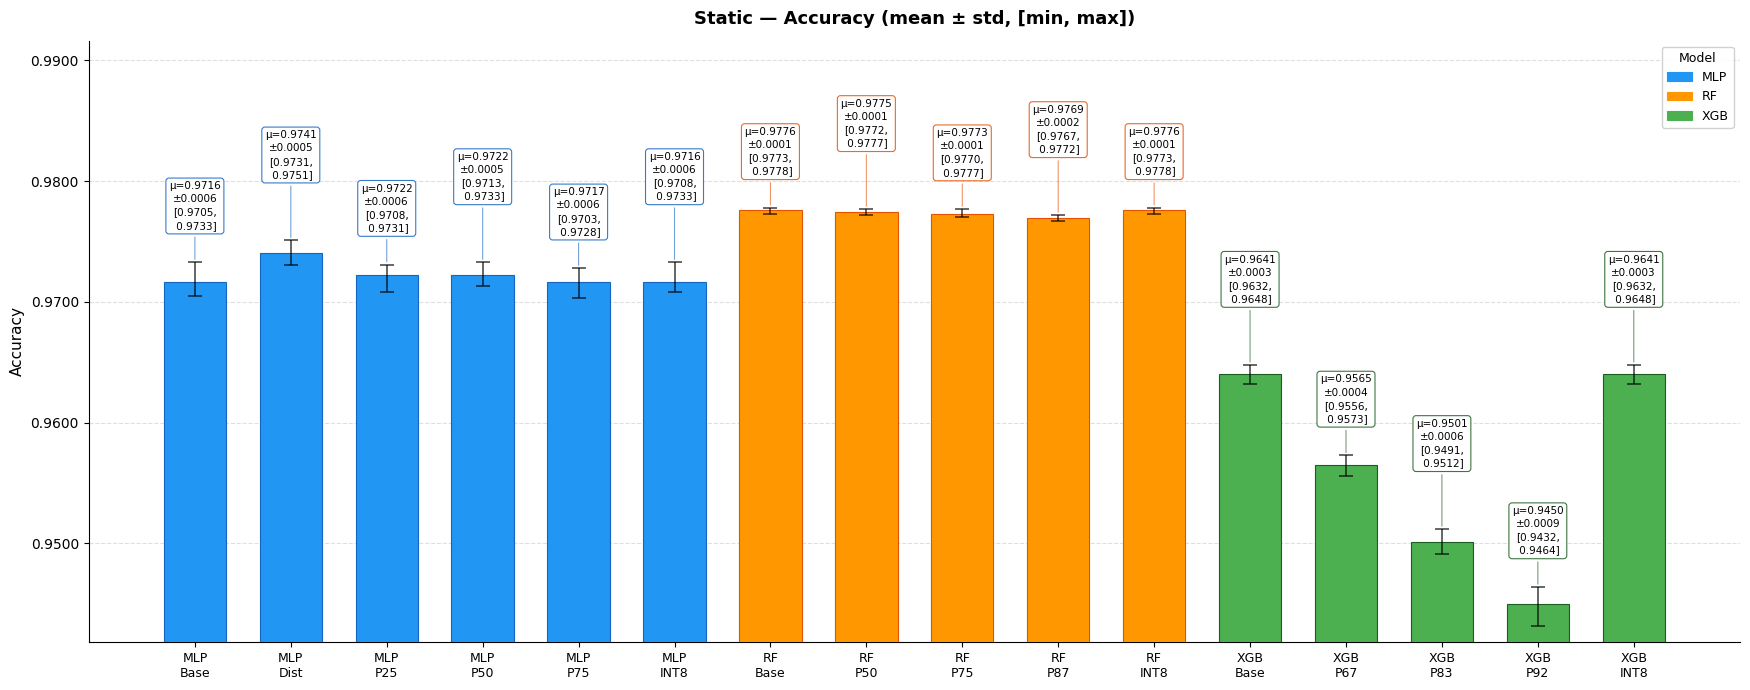

Saved: rq2_static_F1.png


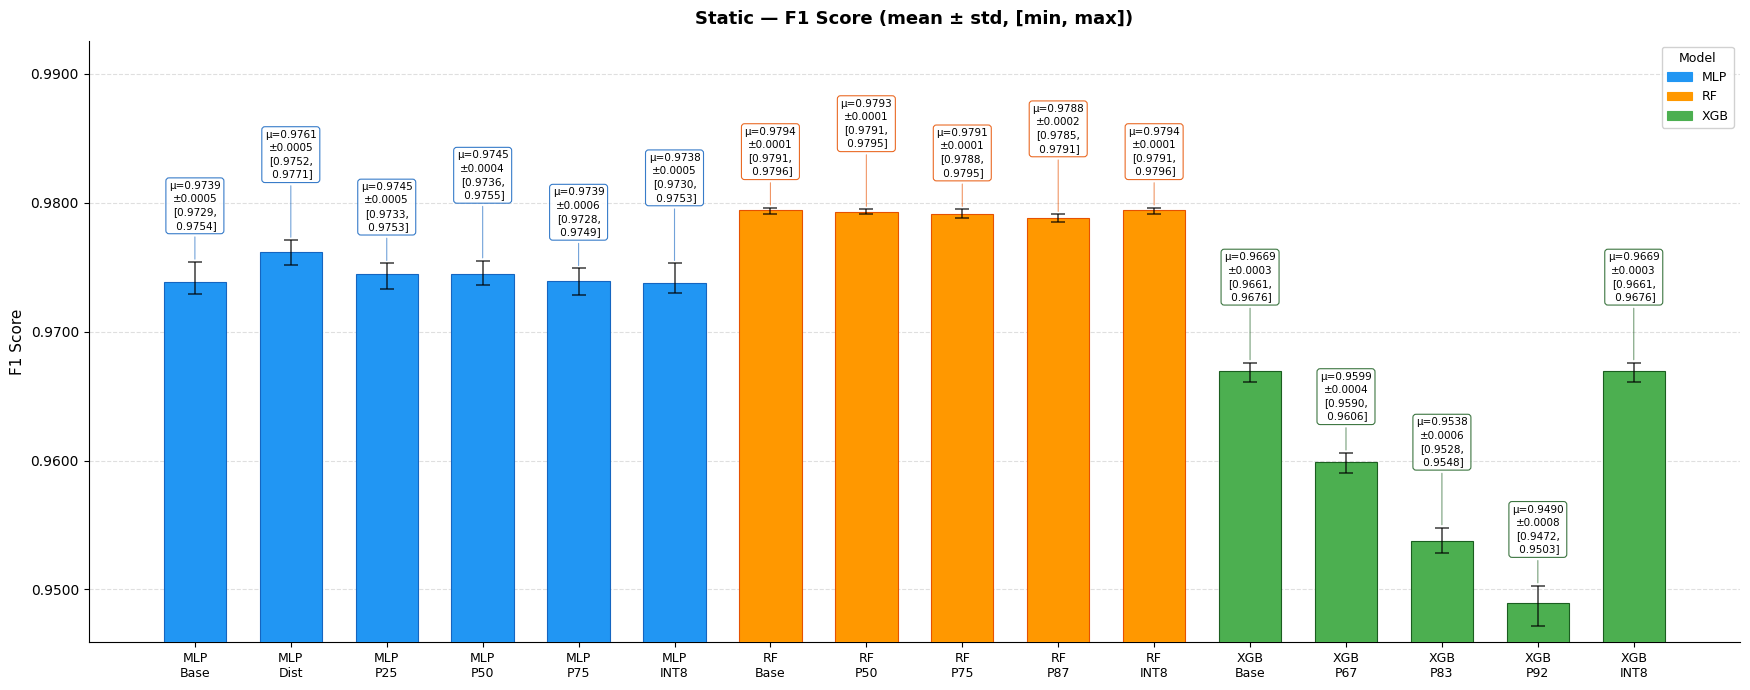

Saved: rq2_static_Size.png


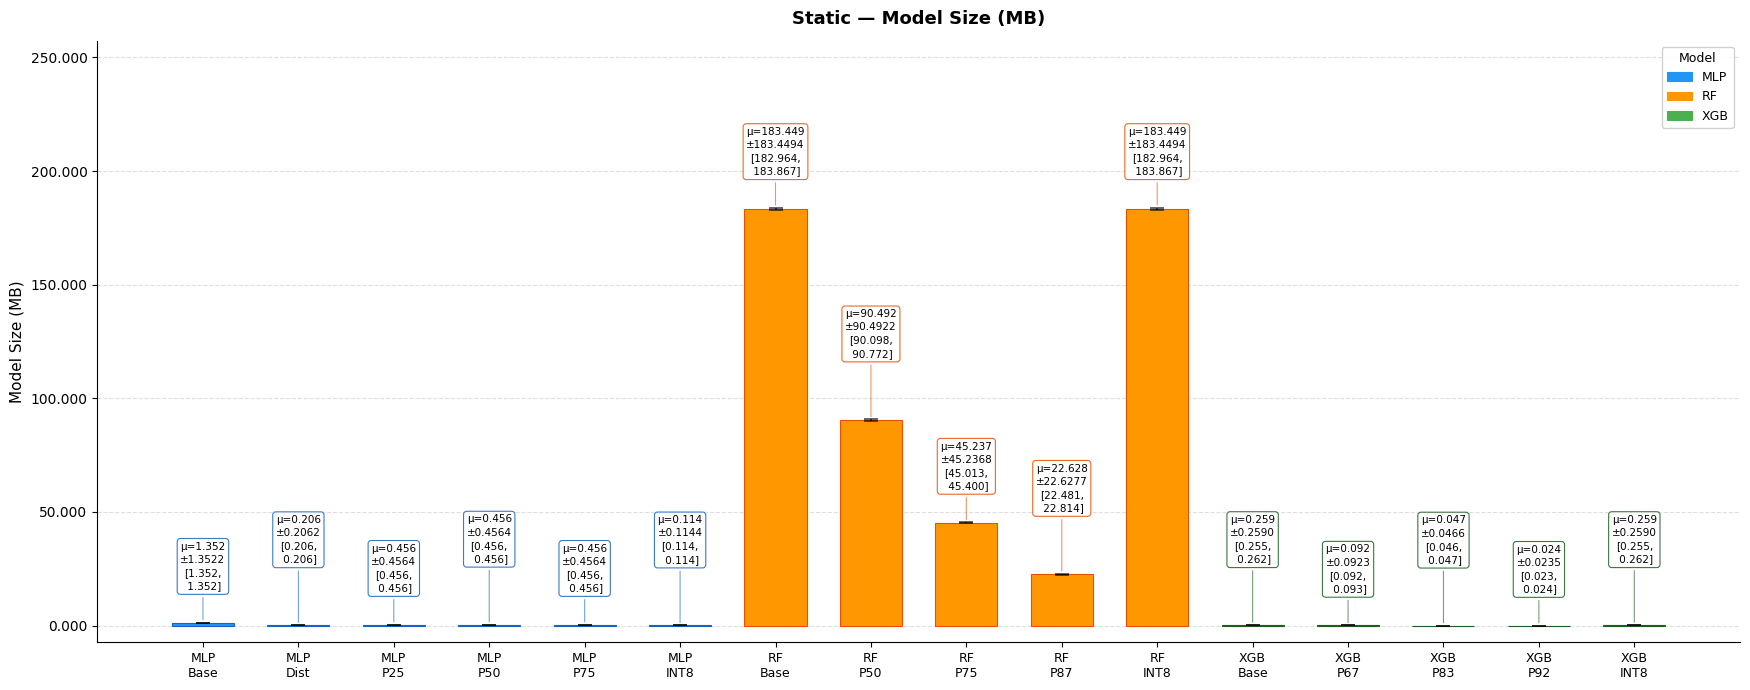

Saved: rq2_static_Drop.png


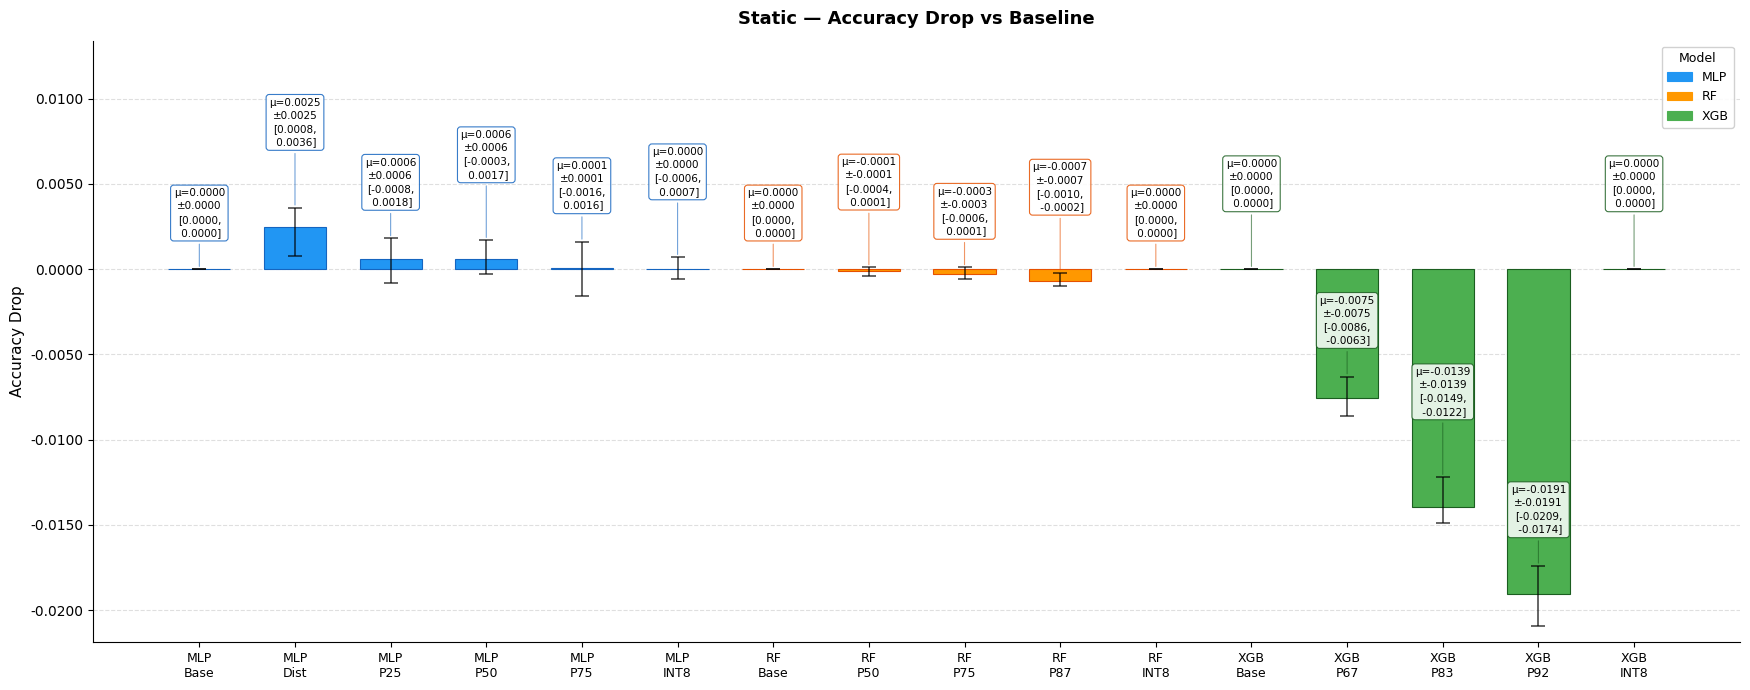

Saved: rq2_dynamic_Acc.png


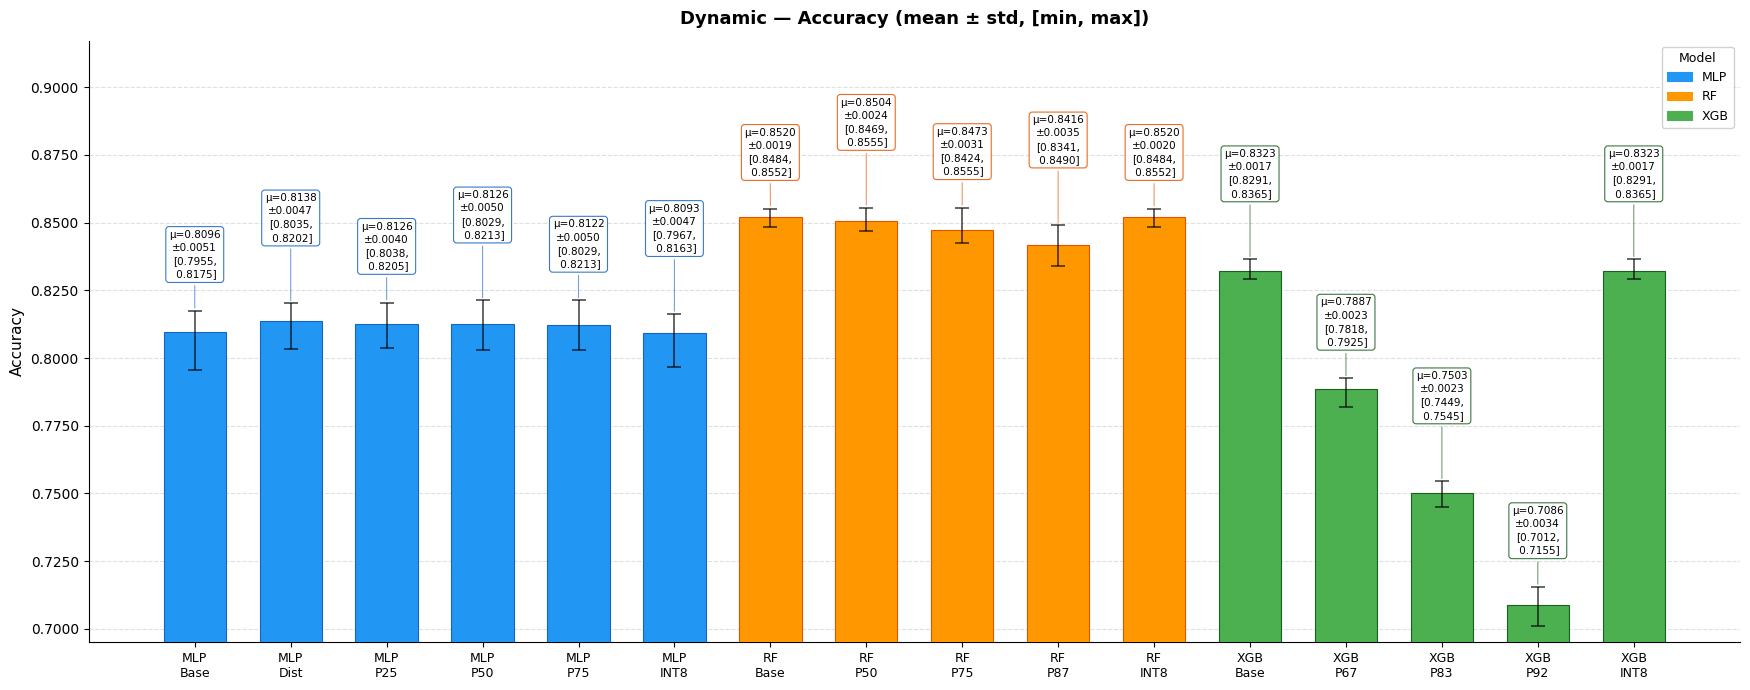

Saved: rq2_dynamic_F1.png


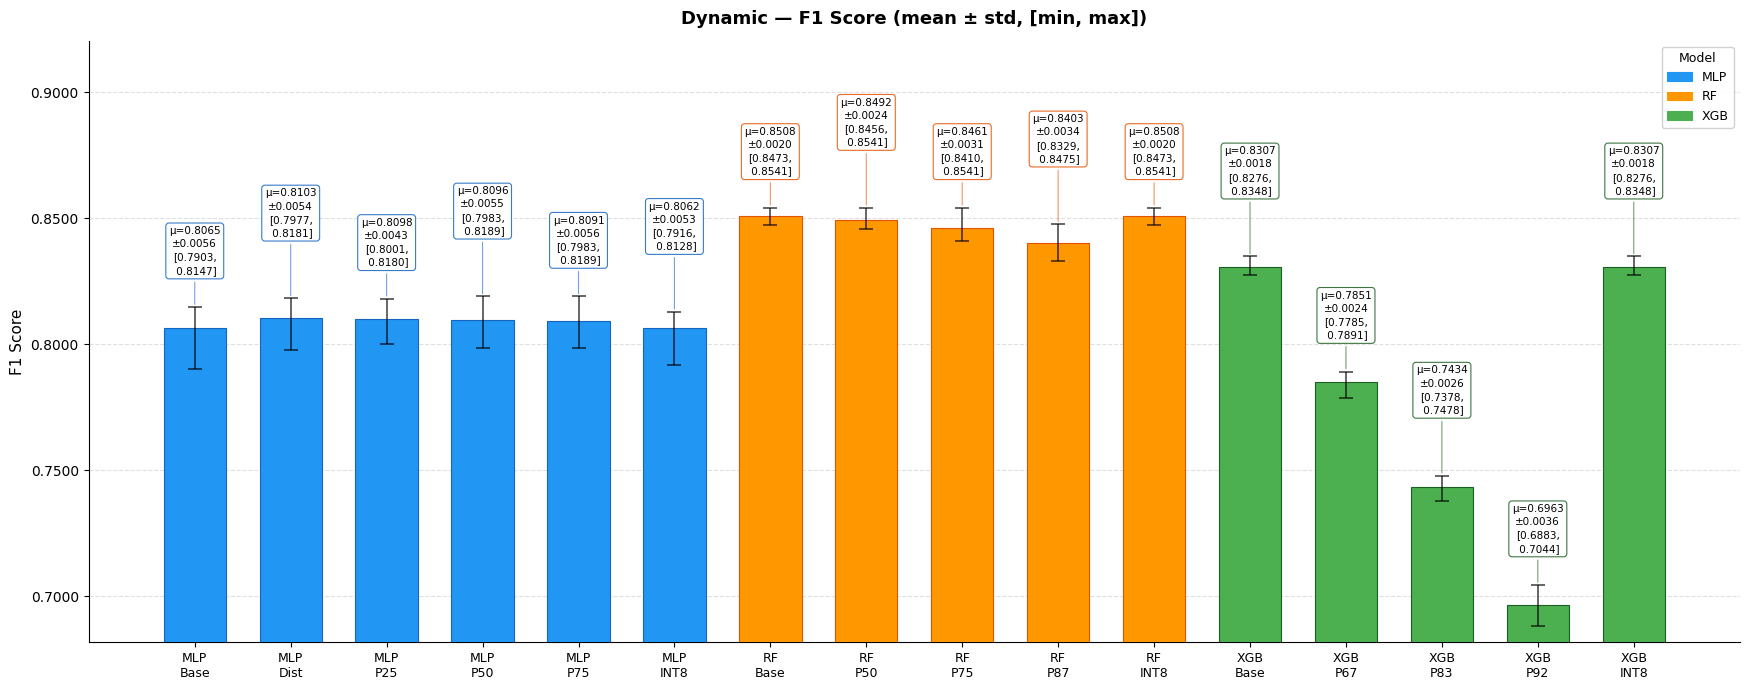

Saved: rq2_dynamic_Size.png


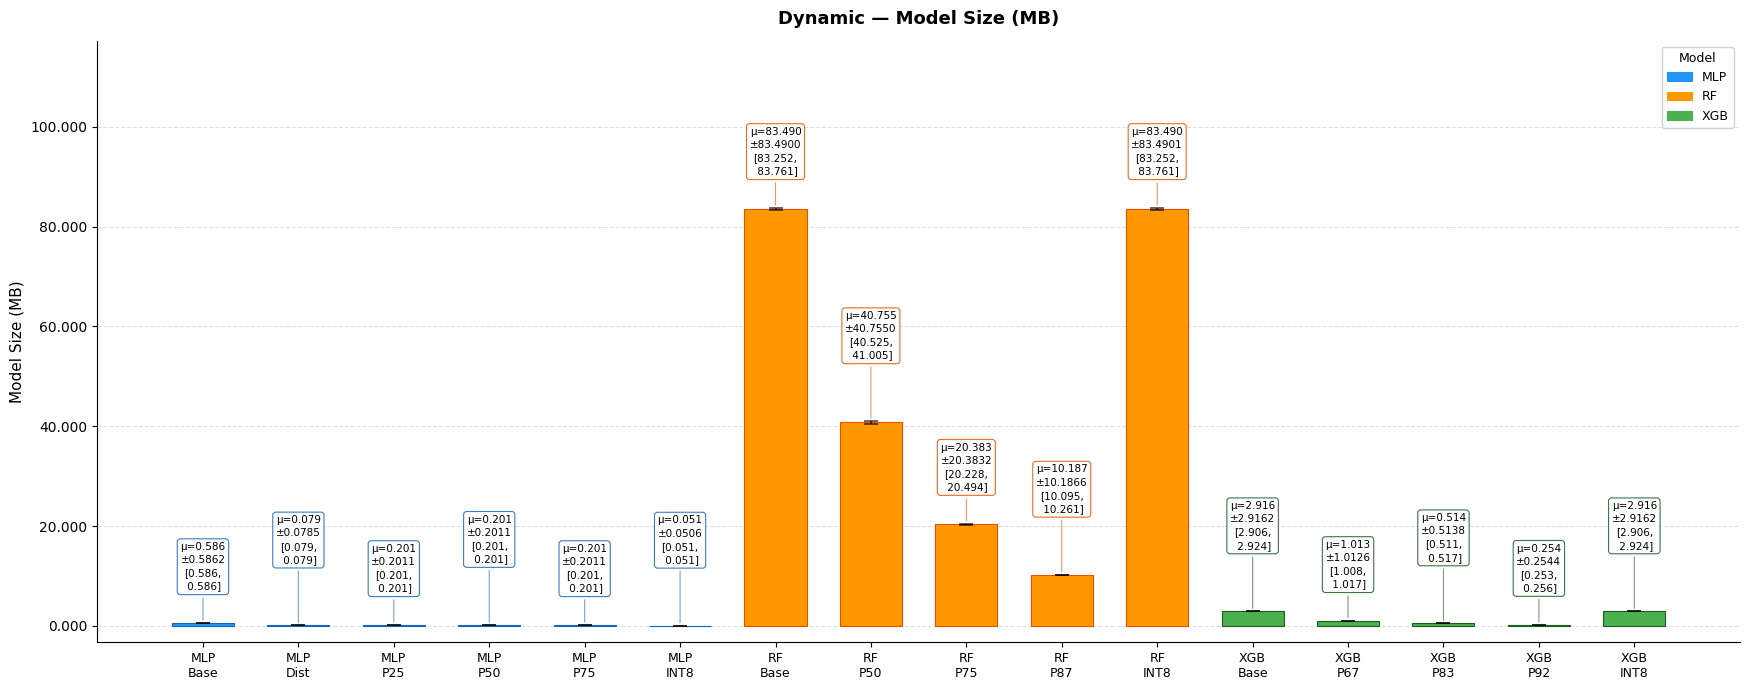

Saved: rq2_dynamic_Drop.png


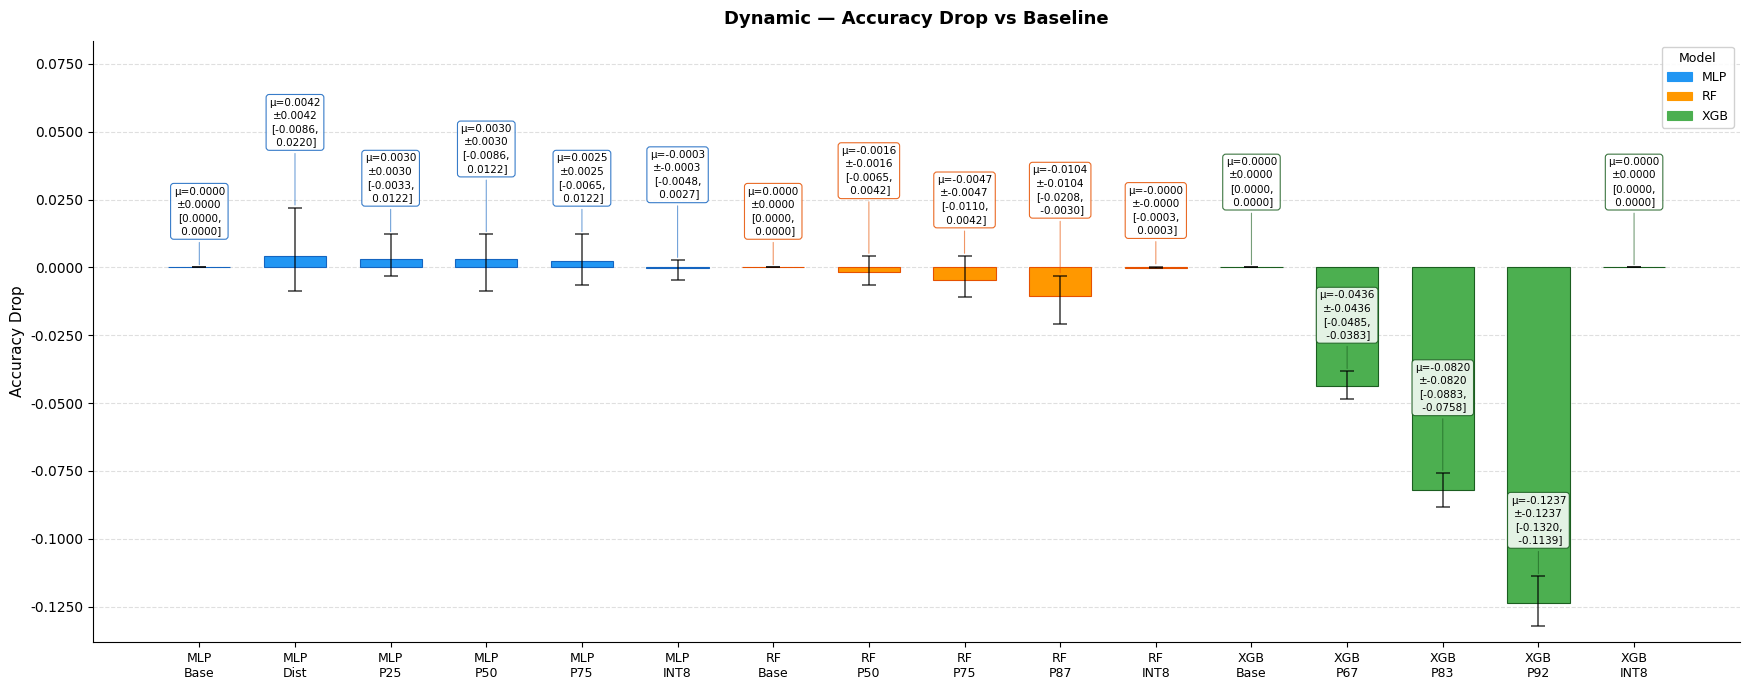

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("rq2_results_30seed.csv")

# -----------------------------
# Aggregate statistics
# -----------------------------
agg = df.groupby(
    ["Model", "Dataset", "Technique"]
).agg(
    Acc_mean=("Accuracy", "mean"),
    Acc_std=("Accuracy", "std"),
    Acc_min=("Accuracy", "min"),
    Acc_max=("Accuracy", "max"),
    F1_mean=("F1", "mean"),
    F1_std=("F1", "std"),
    F1_min=("F1", "min"),
    F1_max=("F1", "max"),
    Size_mean=("Size_MB", "mean"),
    Size_min=("Size_MB", "min"),
    Size_max=("Size_MB", "max"),
    Drop_mean=("Acc_Drop", "mean"),
    Drop_min=("Acc_Drop", "min"),
    Drop_max=("Acc_Drop", "max"),
).reset_index()

# -----------------------------
# Style config
# -----------------------------
MODEL_COLORS = {
    "MLP": "#2196F3",
    "RF":  "#FF9800",
    "XGB": "#4CAF50"
}

MODEL_EDGE = {
    "MLP": "#1565C0",
    "RF":  "#E65100",
    "XGB": "#1B5E20"
}

plt.rcParams.update({
    "font.family":  "DejaVu Sans",
    "font.size":    10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# -----------------------------
# Plotting function
# -----------------------------
def plot_metric(data,
                dataset_name,
                mean_col,
                min_col,
                max_col,
                std_col,
                ylabel,
                title,
                fmt=".4f",
                save_path=None):

    data = data.copy().reset_index(drop=True)

    # Short labels
    tech_short = {
        "Baseline":               "Base",
        "Quantization INT8":      "INT8",
        "Pruning 25%":            "P25",
        "Pruning 50%":            "P50",
        "Pruning 75%":            "P75",
        "Pruning 50% (100 trees)":"P50",
        "Pruning 75% (50 trees)": "P75",
        "Pruning 87% (25 trees)": "P87",
        "Pruning 67% (100 rounds)":"P67",
        "Pruning 83% (50 rounds)": "P83",
        "Pruning 92% (25 rounds)": "P92",
        "Distillation (128→64)":  "Dist",
    }

    data["Label"] = (
        data["Model"] + "\n"
        + data["Technique"].map(
            lambda x: tech_short.get(x, x))
    )

    n = len(data)
    x = np.arange(n)
    means  = data[mean_col].values
    stds   = data[std_col].values \
             if std_col in data.columns \
             else np.zeros(n)
    mins   = data[min_col].values
    maxs   = data[max_col].values
    colors = [MODEL_COLORS[m] 
              for m in data["Model"]]
    edges  = [MODEL_EDGE[m]  
              for m in data["Model"]]

    lower_err = means - mins
    upper_err = maxs  - means

    # ── Figure ──────────────────────────
    fig, ax = plt.subplots(
        figsize=(max(14, n * 1.1), 7))

    bars = ax.bar(
        x,
        means,
        color=colors,
        edgecolor=edges,
        linewidth=0.8,
        yerr=[lower_err, upper_err],
        error_kw=dict(
            ecolor="black",
            capsize=5,
            capthick=1.2,
            elinewidth=1.2,
            alpha=0.7
        ),
        width=0.65,
        zorder=3
    )

    # ── Annotations ─────────────────────
    # Alternate annotation height to avoid
    # overlap on adjacent bars
    yrange = maxs.max() - mins.min()
    base_offset = yrange * 0.015

    for i, bar in enumerate(bars):
        bx    = bar.get_x() + bar.get_width()/2
        top   = maxs[i]
        std_v = stds[i]
        mean_v= means[i]
        min_v = mins[i]
        max_v = maxs[i]

        # Alternate between above/inside bar
        # to avoid crowding
        offset = base_offset + \
                 (yrange * 0.06 
                  if i % 2 == 0 
                  else yrange * 0.13)

        ann_y = top + offset

        # Annotation box
        ax.annotate(
            f"μ={mean_v:{fmt}}\n"
            f"±{std_v:.4f}\n"
            f"[{min_v:{fmt}},\n"
            f" {max_v:{fmt}}]",
            xy=(bx, top),
            xytext=(bx, ann_y),
            ha="center",
            va="bottom",
            fontsize=7.5,
            linespacing=1.4,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor=edges[i],
                alpha=0.85,
                linewidth=0.8
            ),
            arrowprops=dict(
                arrowstyle="-",
                color=edges[i],
                lw=0.8,
                alpha=0.6
            )
        )

    # ── Axis ────────────────────────────
    ax.set_xticks(x)
    ax.set_xticklabels(
        data["Label"],
        rotation=0,
        ha="center",
        fontsize=9
    )
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(
        f"{dataset_name} — {title}",
        fontsize=13,
        fontweight="bold",
        pad=12
    )

    # Y limits with room for annotations
    annotation_room = yrange * 0.40
    ax.set_ylim(
        mins.min() - yrange * 0.04,
        maxs.max() + annotation_room
    )

    ax.yaxis.set_major_formatter(
        mticker.FormatStrFormatter(
            f"%{fmt}"))
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4,
        zorder=0
    )

    # ── Legend ──────────────────────────
    legend_handles = [
        Patch(
            color=MODEL_COLORS[m],
            edgecolor=MODEL_EDGE[m],
            label=m,
            linewidth=0.8
        )
        for m in ["MLP", "RF", "XGB"]
    ]
    ax.legend(
        handles=legend_handles,
        title="Model",
        title_fontsize=9,
        fontsize=9,
        loc="upper right",
        framealpha=0.9
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=180,
            bbox_inches="tight"
        )
        print(f"Saved: {save_path}")

    plt.show()
    plt.close()


# =====================================================
# GENERATE ALL PLOTS
# =====================================================

metrics = [
    ("Acc_mean",  "Acc_min",  "Acc_max",
     "Acc_std",
     "Accuracy",
     "Accuracy (mean ± std, [min, max])",
     ".4f"),

    ("F1_mean",   "F1_min",   "F1_max",
     "F1_std",
     "F1 Score",
     "F1 Score (mean ± std, [min, max])",
     ".4f"),

    ("Size_mean", "Size_min", "Size_max",
     None,
     "Model Size (MB)",
     "Model Size (MB)",
     ".3f"),

    ("Drop_mean", "Drop_min", "Drop_max",
     None,
     "Accuracy Drop",
     "Accuracy Drop vs Baseline",
     ".4f"),
]

for dataset_name in ["Static", "Dynamic"]:

    subset = agg[
        agg["Dataset"] == dataset_name
    ].copy()

    for (mean_c, min_c, max_c,
         std_c, ylabel, title, fmt) \
            in metrics:

        # Skip std if not available
        use_std = std_c \
            if std_c and std_c in subset.columns \
            else mean_c

        plot_metric(
            data=subset,
            dataset_name=dataset_name,
            mean_col=mean_c,
            min_col=min_c,
            max_col=max_c,
            std_col=use_std,
            ylabel=ylabel,
            title=title,
            fmt=fmt,
            save_path=(
                f"rq2_{dataset_name.lower()}"
                f"_{mean_c.replace('_mean','')}"
                f".png"
            )
        )

## 7. Cleanup temporary models (optional)

In [14]:
# Per-seed temp models can take ~2-5 GB. Uncomment to clean up after aggregation.

# import shutil
# if os.path.exists(TMP_DIR):
#     shutil.rmtree(TMP_DIR)
#     print(f"✓ Removed {TMP_DIR}/")

import os
if os.path.exists(TMP_DIR):
    n_files = len(os.listdir(TMP_DIR))
    total_mb = sum(os.path.getsize(os.path.join(TMP_DIR, f))
                   for f in os.listdir(TMP_DIR)) / (1024 * 1024)
    print(f"{TMP_DIR}/ : {n_files} files, {total_mb:.0f} MB")
    print("Uncomment the shutil.rmtree line above to free disk space.")

rq2_30seed_tmp/ : 960 files, 23286 MB
Uncomment the shutil.rmtree line above to free disk space.
